# 04: Distance metrics: Levenshtein, Jaccard, normalised TED

Continuous distances in `[0, 1]` (0 = identical). Token Levenshtein, token-set Jaccard, and normalised tree-edit distance over a shallow clause tree (APTED) -- all from `eval_harness.canonical`, shared with 03. Computed for every target present (Cypher and AQL), kept separate in the summary tables and figures below. An identity test (gold vs itself -> all distances 0.0) runs first.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "evaluation"))

import pandas as pd
from eval_harness import load_records, load_dataset, OUTPUTS_DIR
from eval_harness.config import DATASETS_DIR
from eval_harness.canonical import levenshtein, jaccard, normalized_ted

OUT_CSV = OUTPUTS_DIR / 'metrics_distance.csv'

## Identity sanity test

In [2]:
identity_rows = []
for ds_path in sorted(DATASETS_DIR.glob('*.yaml')):
    for q in load_dataset(ds_path.stem):
        for target, ref in q.expected.items():
            identity_rows.append((ds_path.stem, q.id, target,
                                  levenshtein(ref, ref, target), jaccard(ref, ref, target),
                                  normalized_ted(ref, ref, target)))
identity_df = pd.DataFrame(identity_rows, columns=['dataset','query_id','target','lev','jac','ted'])
non_zero = identity_df[(identity_df[['lev','jac','ted']] > 1e-9).any(axis=1)]
print(f'Identity test: {len(identity_df)} cases; non-zero: {len(non_zero)}')
if len(non_zero):
    display(non_zero)
    raise AssertionError('Identity sanity test failed: a distance metric has a bug.')
print('PASS')

Identity test: 56 cases; non-zero: 0
PASS


## Compute on the real records

In [3]:
records = load_records(OUTPUTS_DIR)
keys = ['dataset','target','model','query_id','difficulty']
rows = []
for r in records:
    translated = r.get('generated_query'); expected = r['expected_query']; target = r['target']
    base = {k: r[k] for k in keys}
    if not translated:
        rows.append({**base, 'levenshtein': 1.0, 'jaccard': 1.0, 'normalized_ted': 1.0}); continue
    rows.append({**base, 'levenshtein': levenshtein(translated, expected, target),
                 'jaccard': jaccard(translated, expected, target),
                 'normalized_ted': normalized_ted(translated, expected, target)})
dist_df = pd.DataFrame(rows)
dist_df.head(8)

,dataset,target,model,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc,aql,claude-opus-4-8,ldbc_q01,easy,0.071429,0.142857,0.069767
1,ldbc,aql,claude-opus-4-8,ldbc_q02,easy,0.000000,0.000000,0.000000
2,ldbc,aql,claude-opus-4-8,ldbc_q03,easy,0.033333,0.117647,0.032258
3,ldbc,aql,claude-opus-4-8,ldbc_q04,hard,0.282609,0.074074,0.276596
4,ldbc,aql,claude-opus-4-8,ldbc_q05,hard,0.481013,0.270270,0.500000
5,ldbc,aql,claude-opus-4-8,ldbc_q06,medium,0.125000,0.120000,0.122449
6,ldbc,aql,claude-opus-4-8,ldbc_q07,medium,0.147059,0.100000,0.144928
7,ldbc,aql,claude-opus-4-8,ldbc_q08,hard,0.193548,0.100000,0.191489


## Summaries (lower is better)

In [4]:
metric_cols = ['levenshtein','jaccard','normalized_ted']
print('By dataset x target x model:')
display(dist_df.groupby(['dataset','target','model'])[metric_cols].mean())
print('By target x difficulty:')
_bd = dist_df.copy()
_bd['difficulty'] = pd.Categorical(_bd['difficulty'], ['easy','medium','hard'], ordered=True)
display(_bd.groupby(['target','difficulty'], observed=True)[metric_cols].mean())

By dataset x target x model:


levenshtein   jaccard  normalized_ted
dataset target model                                                 
ldbc    aql    claude-opus-4-8     0.220214  0.124075        0.218294
               gemma4:26b          0.213452  0.117760        0.218133
               llama3.2:latest     0.382049  0.366068        0.397968
               qwen3-coder:30b     0.293129  0.189335        0.296779
        cypher claude-opus-4-8     0.071161  0.019907        0.070899
               gemma4:26b          0.054530  0.012183        0.054188
               llama3.2:latest     0.393579  0.283746        0.401815
               qwen3-coder:30b     0.170263  0.080127        0.177632

By target x difficulty:


levenshtein   jaccard  normalized_ted
target difficulty                                       
aql    easy           0.039449  0.097766        0.038357
       medium         0.309300  0.232215        0.314779
       hard           0.360772  0.224025        0.369274
cypher easy           0.080400  0.071573        0.078618
       medium         0.231753  0.124173        0.238072
       hard           0.177880  0.096351        0.182533

In [5]:
dist_df.to_csv(OUT_CSV, index=False)
print(f'Wrote {len(dist_df)} rows to {OUT_CSV}')

Wrote 112 rows to /Users/ivona.obonova/school/rows2graph/rows2graph/evaluation/outputs/metrics_distance.csv


## Visualizations: per target (Cypher and AQL kept separate)

Each target gets its own subsection: per-model distance distributions (boxplots) and a per-query normalized-TED matrix. Figures use a target prefix (`cypher_*`, `aql_*`). All distances are in [0, 1] where lower is better.

In [6]:
from eval_harness import plots, REPORTS_DIR
FIG_DIR = REPORTS_DIR / 'figures'; FIG_DIR.mkdir(parents=True, exist_ok=True)

def render_distance(sub, prefix, label):
    """All distance figures for one target only (prefix -> figure filenames)."""
    if sub.empty:
        print(f'No {label} records to plot.'); return
    models = plots.model_axis(sub); queries = plots.query_axis(sub)
    print(f'{label}: {len(models)} model(s): {models}')
    p = FIG_DIR / f'{prefix}_distance_by_model.png'
    plots.distance_boxplots(sub, p); plots.show(p)
    p = FIG_DIR / f'{prefix}_query_model_ted.png'
    plots.query_model_heatmap(sub, 'normalized_ted', p, cmap_name='viridis_r', models=models, queries=queries,
                              title=f'{label}: normalized TED by query x model (lower = better)', cbar_label='TED')
    plots.show(p)

### SQL → Cypher

SQL -> Cypher: 4 model(s): ['claude-opus-4-8', 'gemma4:26b', 'llama3.2:latest', 'qwen3-coder:30b']


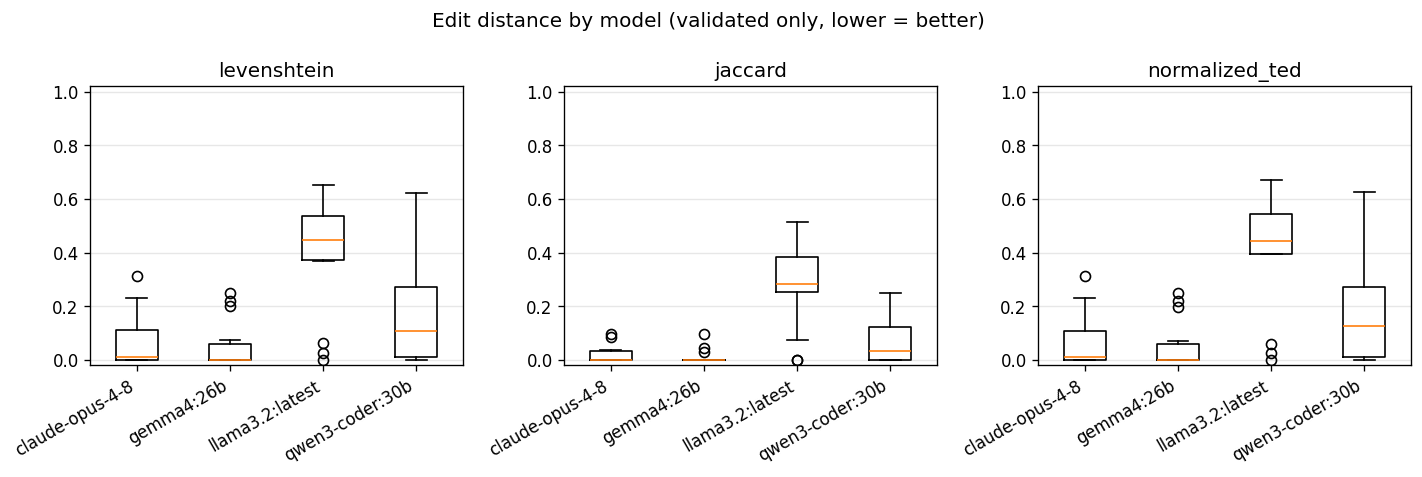

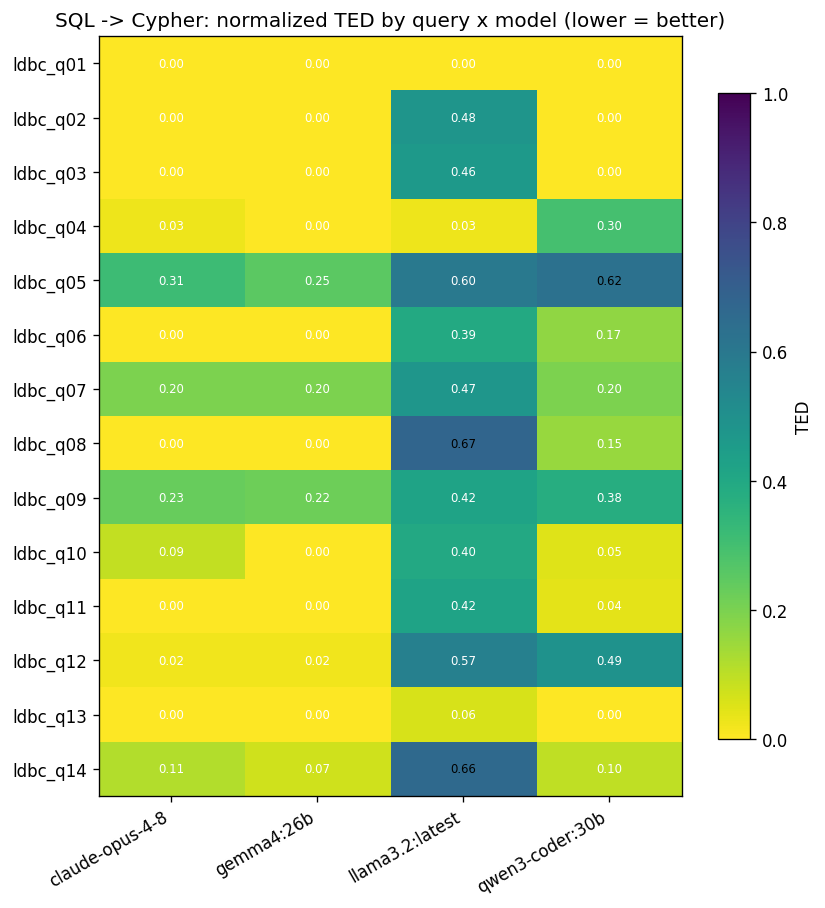

In [7]:
render_distance(dist_df[dist_df['target'] == 'cypher'], 'cypher', 'SQL -> Cypher')

### SQL → AQL

SQL -> AQL: 4 model(s): ['claude-opus-4-8', 'gemma4:26b', 'llama3.2:latest', 'qwen3-coder:30b']


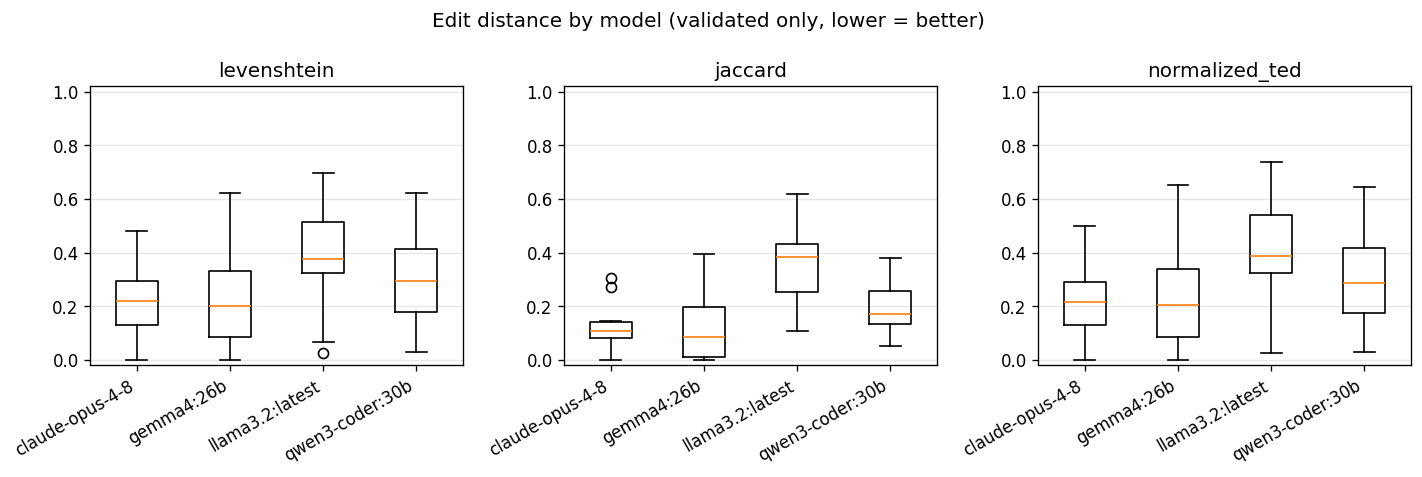

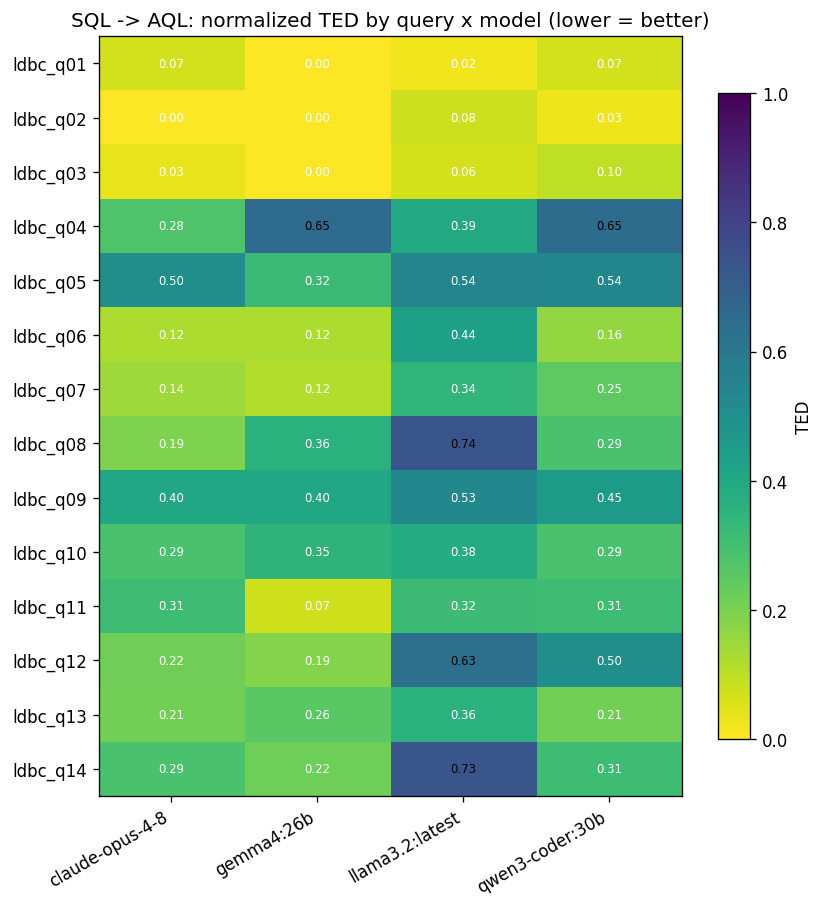

In [8]:
render_distance(dist_df[dist_df['target'] == 'aql'], 'aql', 'SQL -> AQL')